In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [86]:
import pandas as pd
import numpy as np

# 1. Veri Yükleme
path = "/content/drive/MyDrive/veri setleri/heart_disease_uci.csv"
data = pd.read_csv(path)


In [5]:
display("son 5 Satır:")
data.tail()

'son 5 Satır:'

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [87]:
data.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


In [6]:
data.shape

(920, 16)

In [7]:
data.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [8]:
data.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
data.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [12]:
# 1. Eksik Veri Analizi
print("Eksik Veri Analizi:")
missing_data = data.isnull().sum()
missing_percentage = (missing_data / len(data)) * 100
print(pd.DataFrame({'Eksik Veri Sayısı': missing_data, 'Eksik Veri Yüzdesi (%)': missing_percentage}))

Eksik Veri Analizi:
          Eksik Veri Sayısı  Eksik Veri Yüzdesi (%)
id                        0                0.000000
age                       0                0.000000
sex                       0                0.000000
dataset                   0                0.000000
cp                        0                0.000000
trestbps                 59                6.413043
chol                     30                3.260870
fbs                      90                9.782609
restecg                   2                0.217391
thalch                   55                5.978261
exang                    55                5.978261
oldpeak                  62                6.739130
slope                   309               33.586957
ca                      611               66.413043
thal                    486               52.826087
num                       0                0.000000


In [17]:
data_dropped_columns = data.dropna(axis=1)  #eksik verileri sildik  bunu genelde tercih etmeyiz
print(data_dropped_columns.isnull().sum()) # sildikten sonraki veriler                                     # tabi burada asıl veritabanını değiştirmedik. farklı bir değişkene atadık.

id         0
age        0
sex        0
dataset    0
cp         0
num        0
dtype: int64


In [24]:
data_dropped_cabinThal = data.drop(columns=["ca"])  # eğer istersek sadece bir sütunu da silebiliriz
data_dropped_cabinThal.drop(columns=["thal"], inplace=True) # ek olarak thal sütununu da buradaki setten sildik (data_dropped_cabinThal)    #inplace true yazmamız veritabanında kalıcı olmasını sağlıyor.
print(data_dropped_cabinThal.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
num           0
dtype: int64


artık data_dropped_cabinThal kullanacağız çünkü buradaki sütunları sildik.


In [ ]:
from sklearn.impute import SimpleImputer            #simple imputer ile medyan alma
imputer = SimpleImputer(strategy='median')
data['thalch_imputed'] = imputer.fit_transform(data[['thalch']])
print("\n'SimpleImputer' ile doldurulan 'thalch' sütununun son 5 değeri:")
print(data[['thalch', 'thalch_imputed']].tail(10))




'SimpleImputer' ile doldurulan 'thalch' sütununun ilk 5 değeri:
     thalch  thalch_imputed
910    96.0            96.0
911   108.0           108.0
912   128.0           128.0
913   138.0           138.0
914   126.0           126.0
915   154.0           154.0
916   140.0           140.0
917   100.0           100.0
918   140.0           140.0
919    93.0            93.0


In [ ]:
imputer = SimpleImputer(strategy='median')
data['thalch'] = imputer.fit_transform(data[['thalch']])
print("\n'SimpleImputer' ile doldurulan 'thalch' sütununun son 5 değeri:")
print(data[['thalch']].tail(10))

#thalch değerini dataya atadım çünkü burda bana böyle lazım


'SimpleImputer' ile doldurulan 'thalch' sütununun son 5 değeri:
     thalch
910    96.0
911   108.0
912   128.0
913   138.0
914   126.0
915   154.0
916   140.0
917   100.0
918   140.0
919    93.0


In [27]:
 data['chol'] = data['chol'].fillna(data['chol'].mean())

In [28]:
data.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,0
fbs,90
restecg,2
thalch,55


In [33]:


df = pd.DataFrame(data["chol"])


# Aykırı değerleri belirlemek için IQR hesaplama
Q1 = df['chol'].quantile(0.25) #Q1 Pozisyonu=(n+1)×0.25
print("Q1= ",Q1)
Q3 = df['chol'].quantile(0.75)#Q3 Pozisyonu=(n+1)×0.75
print("Q3= ",Q3)
IQR = Q3 - Q1
print("IQR= ",IQR)
print(" ")

# Alt ve üst sınırları belirleme
lower_limit = Q1 - 1.5 * IQR
print("alt sınır",lower_limit)
upper_limit = Q3 + 1.5 * IQR
print("üst sınır",upper_limit)
print(" ")

# Aykırı değerleri tespit etme
outliers = df[(df['chol'] < lower_limit) | (df['chol'] > upper_limit)]
print("Aykırı Değerler:\n", outliers)


Q1=  177.75
Q3=  267.0
IQR=  89.25
 
alt sınır 43.875
üst sınır 400.875
 
Aykırı Değerler:
       chol
48   417.0
121  407.0
152  564.0
181  409.0
373  412.0
..     ...
818    0.0
819    0.0
822    0.0
839    0.0
840    0.0

[185 rows x 1 columns]


In [77]:
# 1. Veri tekrar yükleyelim çünkü hepsinin ortalama veya modunu alacağız
path = "/content/drive/MyDrive/veri setleri/heart_disease_uci.csv"
data = pd.read_csv(path)

In [79]:
# Sadece sayısal sütunları seçelim
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns #numbers de kullanabiliriz float int yerine
print("\nSayısal Sütunlar:")
print(numeric_columns)


Sayısal Sütunlar:
Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')


In [80]:
#sadece kategorik sütunları alalım
categoric_columns = data.select_dtypes(include=['object']).columns
print("\nkategorik Sütunlar:")
print(numeric_columns)


kategorik Sütunlar:
Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')


In [81]:
for col in numeric_columns:                                                                         #aykırı değer analizinden önce eksik sütunları ortalama ile doldurduk
    print(f"\n--- {col} Sütunu ---")

    # Eksik değer kontrolü ve doldurma
    if data[col].isnull().sum() > 0:
        print(f"{col} sütununda {data[col].isnull().sum()} eksik değer var. Dolduruluyor...")
        data[col].fillna(data[col].mean(), inplace=True)  # Eksik değerleri sütunun ortalaması ile doldur



--- id Sütunu ---

--- age Sütunu ---

--- trestbps Sütunu ---
trestbps sütununda 59 eksik değer var. Dolduruluyor...

--- chol Sütunu ---
chol sütununda 30 eksik değer var. Dolduruluyor...

--- thalch Sütunu ---
thalch sütununda 55 eksik değer var. Dolduruluyor...

--- oldpeak Sütunu ---
oldpeak sütununda 62 eksik değer var. Dolduruluyor...

--- ca Sütunu ---
ca sütununda 611 eksik değer var. Dolduruluyor...

--- num Sütunu ---


<ipython-input-81-05668fe22494>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)  # Eksik değerleri sütunun ortalaması ile doldur


In [83]:
for col in categoric_columns:                                                                         #aykırı değer analizinden önce eksik sütunları mod ile doldurduk
    print(f"\n--- {col} Sütunu ---")

    # Eksik değer kontrolü ve doldurma
    if data[col].isnull().sum() > 0:
        print(f"{col} sütununda {data[col].isnull().sum()} eksik değer var. Dolduruluyor...")
        data[col].fillna(data[col].mode()[0], inplace=True)  # Eksik değerleri sütunun ortalaması ile doldur


--- sex Sütunu ---

--- dataset Sütunu ---

--- cp Sütunu ---

--- fbs Sütunu ---
fbs sütununda 90 eksik değer var. Dolduruluyor...

--- restecg Sütunu ---
restecg sütununda 2 eksik değer var. Dolduruluyor...

--- exang Sütunu ---
exang sütununda 55 eksik değer var. Dolduruluyor...

--- slope Sütunu ---
slope sütununda 309 eksik değer var. Dolduruluyor...

--- thal Sütunu ---
thal sütununda 486 eksik değer var. Dolduruluyor...


<ipython-input-83-2b4d33e9a5ce>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)  # Eksik değerleri sütunun ortalaması ile doldur
<ipython-input-83-2b4d33e9a5ce>:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col].fillna(data[col].mode()[0], inplace=Tru

In [84]:
data.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0



--- id Sütunu ---


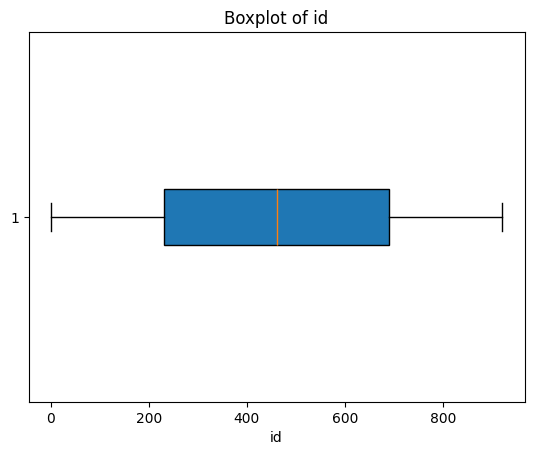

IQR: 459.5, Lower Bound: -458.5, Upper Bound: 1379.5
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 0


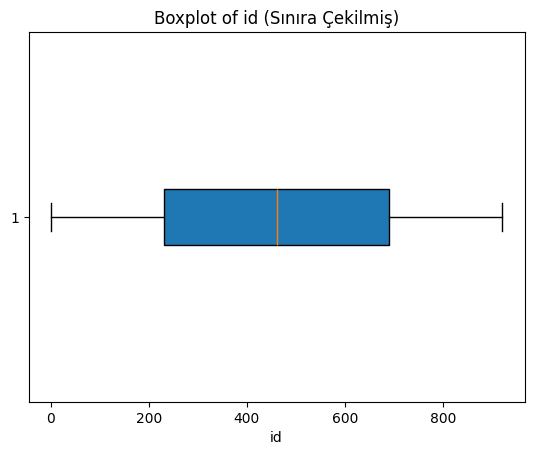


--- age Sütunu ---


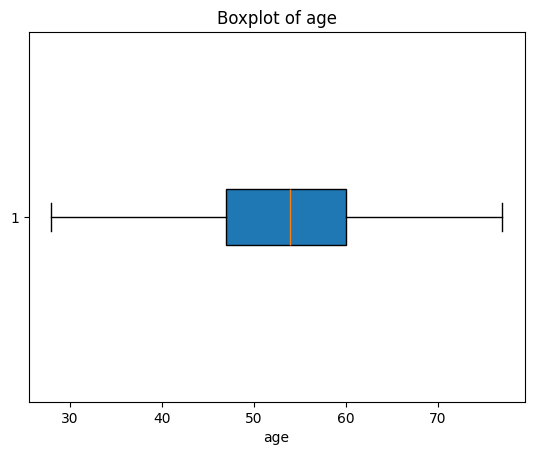

IQR: 13.0, Lower Bound: 27.5, Upper Bound: 79.5
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 0


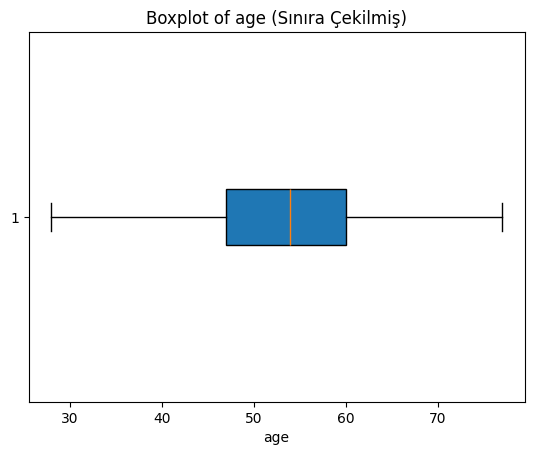


--- trestbps Sütunu ---


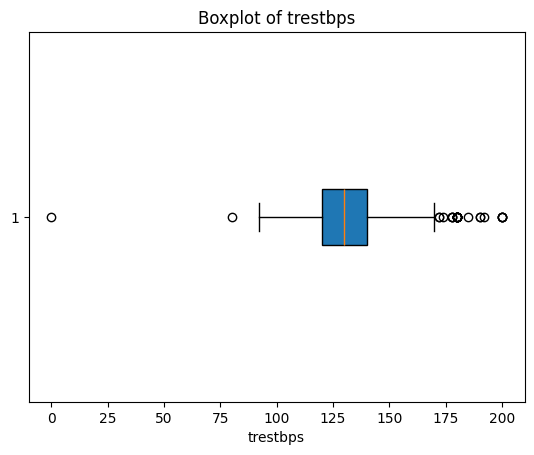

IQR: 20.0, Lower Bound: 90.0, Upper Bound: 170.0
Aykırı Değer Sayısı: 28
Z-Score ile Aykırı Değer Sayısı: 8


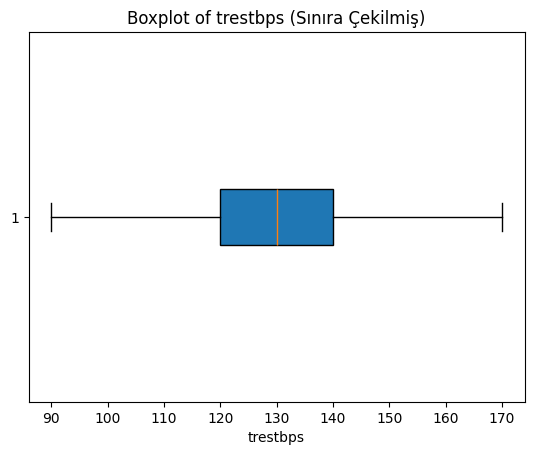


--- chol Sütunu ---


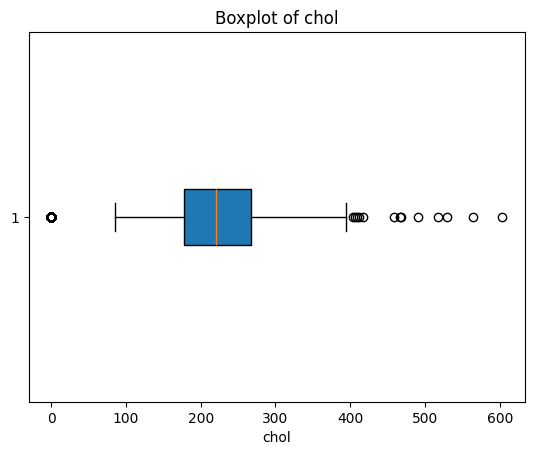

IQR: 89.25, Lower Bound: 43.875, Upper Bound: 400.875
Aykırı Değer Sayısı: 185
Z-Score ile Aykırı Değer Sayısı: 3


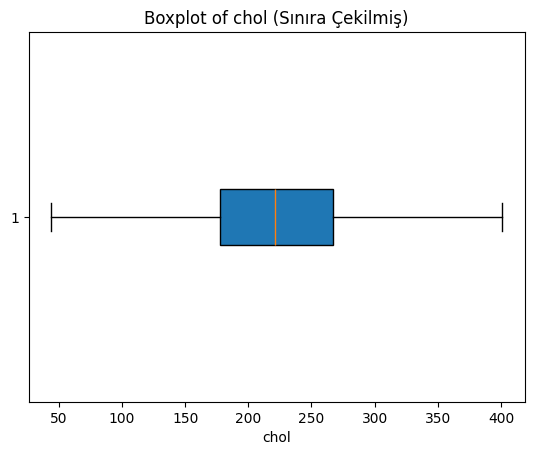


--- thalch Sütunu ---


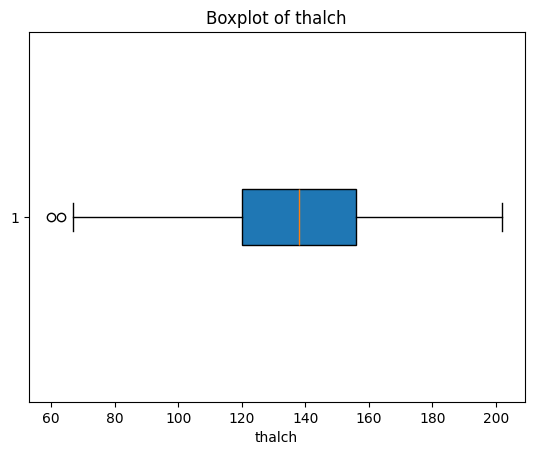

IQR: 36.0, Lower Bound: 66.0, Upper Bound: 210.0
Aykırı Değer Sayısı: 2
Z-Score ile Aykırı Değer Sayısı: 1


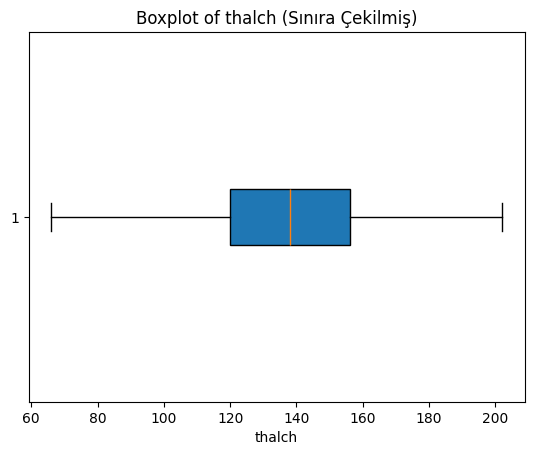


--- oldpeak Sütunu ---


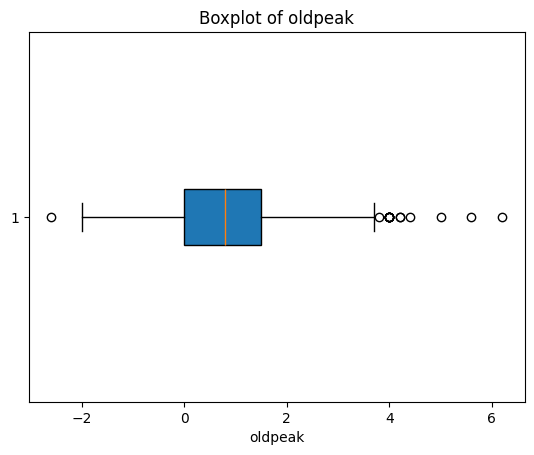

IQR: 1.5, Lower Bound: -2.25, Upper Bound: 3.75
Aykırı Değer Sayısı: 16
Z-Score ile Aykırı Değer Sayısı: 7


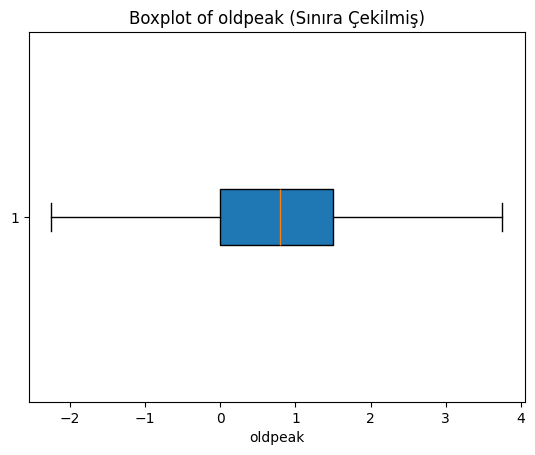


--- ca Sütunu ---


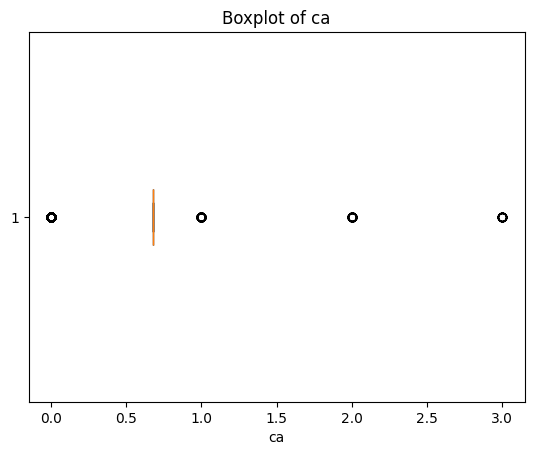

IQR: 0.0, Lower Bound: 0.6763754045307443, Upper Bound: 0.6763754045307443
Aykırı Değer Sayısı: 309
Z-Score ile Aykırı Değer Sayısı: 20


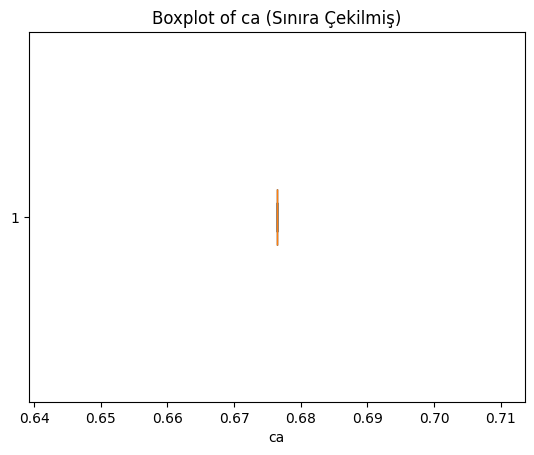


--- num Sütunu ---


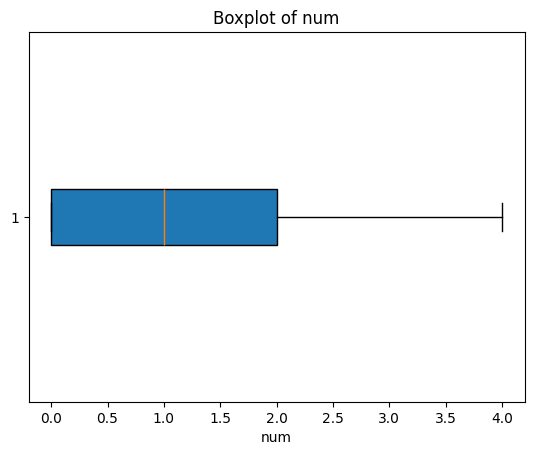

IQR: 2.0, Lower Bound: -3.0, Upper Bound: 5.0
Aykırı Değer Sayısı: 0
Z-Score ile Aykırı Değer Sayısı: 0


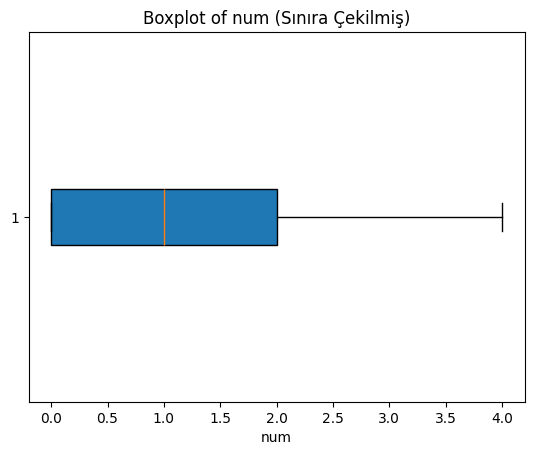

In [85]:
import matplotlib.pyplot as plt #veri görselleştirme kütüphanesi
from scipy.stats import zscore

for col in numeric_columns:
    print(f"\n--- {col} Sütunu ---")


    # Boxplot ile aykırı değerleri görselleştir
    plt.boxplot(data[col], vert=False, patch_artist=True)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

    # IQR yöntemi ile aykırı değer analizi
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"IQR: {IQR}, Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"Aykırı Değer Sayısı: {len(outliers)}")

    # Z-Score yöntemi ile aykırı değer analizi
    z_scores = zscore(data[col])
    outliers_z = data[np.abs(z_scores) > 3]
    print(f"Z-Score ile Aykırı Değer Sayısı: {len(outliers_z)}")

    # Aykırı değerleri sınıra çek
    data[col] = data[col].apply(
        lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x
    )

    # Sınıra çekilmiş veriyi tekrar görselleştir
    plt.boxplot(data[col].dropna(), vert=False, patch_artist=True)
    plt.title(f"Boxplot of {col} (Sınıra Çekilmiş)")
    plt.xlabel(col)
    plt.show()


.

.





**UCI Heart Disease veri seti, kalp hastalığına ilişkin çeşitli faktörleri içeren bir veri setidir. Bu veri seti, bir kişinin kalp hastalığına sahip olup olmadığını tahmin etmek amacıyla kullanılır. UCI Heart Disease veri setinin sütunları aşağıdaki gibi tanımlanabilir:**

#age: (int) – Yaş (tam sayı)

#sex: (int) – Cinsiyet (1 = erkek, 0 = kadın)

#cp: (int) – Göğüs ağrısı tipi (0 = tip 1, 1 = tip 2, 2 = tip 3, 3 = tip 4)

#trestbps: (int) – Dinlenme kan basıncı (mm Hg)

#chol: (int) – Serum kolesterol düzeyi (mg/dl)

#fbs: (int) – Açlık kan şekeri > 120 mg/dl (1 = evet, 0 = hayır)

#restecg: (int) – Dinlenme elektrokardiyogram durumu (0 = normal, 1 = ST-T dalgası değişikliği, 2 = hipertrofi)

#thalach: (int) – Maksimum kalp atış hızı

#exang: (int) – Egzersizle ilişkili angina (1 = evet, 0 = hayır)

#oldpeak: (float) – ST depresyonu (egzersiz sonrası)

#slope: (int) – Egzersiz ST eğimi (0 = yükselen, 1 = düz, 2 = alçalan)

#ca: (int) – Büyük damarların sayısı (0-3 arası)

#thal: (int) – Talasemik durumu (3 = normal, 6 = defekt, 7 = tam kayıp)
